This notebook contains functionality to do more detailed analysis on time slicer results using output from TimeSlicer.py. It can also generate metrics on multiple time sliced files (as long as they use the same thresholds). 
Because we want to pull neutrino truth information to do some of this analysis, we unfortunately do have to load in the last place where neutrino vertices are stored - HitWiseEffects output. 

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import collections
import ROOT as root
import awkward as ak
import uproot
import os
import glob
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

In [75]:
#Functions that are common to both the multi file and single file analysis 

def SortByTime(array):
    sorted_array = array[np.argsort(array[:,5])]
    return(sorted_array)

def SortByNN(array):
    sorted_array = array[np.argsort(array[:,0])]
    return(sorted_array)

#returns an array which contains total merged hits, PEs, for each neutrino event, used for creating metrics.
def ReturnNeutrinoInfoArray(time_sorted_hits, number_of_neutrinos):
    
    neutrino_PE_array_merged = np.zeros((number_of_neutrinos, 3))
    for i in range(number_of_neutrinos):
        PEs = 0.
        sub_array = time_sorted_hits[time_sorted_hits[:, 0] == i]
        n_hits = 0
        for hit in sub_array:
            n_hits += 1
            PEs += hit[6]
        neutrino_PE_array_merged[i][0] = i
        neutrino_PE_array_merged[i][1] = PEs
        neutrino_PE_array_merged[i][2] = n_hits

    return(neutrino_PE_array_merged)
#this function checks how many total events were placed into groups. 
def ValidateEvents(events, hit_array_merged):
    hits_sliced = 0
    for group in events:
        for hit in group:
            hits_sliced += 1
    missing = (np.shape(hit_array_merged)[0] - hits_sliced)
    missing_ratio = missing / np.shape(hit_array_merged)[0]
    print(f"Grouped {hits_sliced} hits into {len(events)} slices, {missing} hits were not grouped, {(missing_ratio * 100):2f}% of total")
    return(hits_sliced, missing, missing_ratio)

            
#This function can print out the time slices, caution it prints a lot lol
def SlicerPrinting(events, loud = False):
    print(f"Detected {len(events)} slices:")
    for i, event in enumerate(events):
        print(f"\n--- Event {i+1} ---")
        total_energy_event = sum(hit_row[6] for hit_row in event) # Sum energy from full rows
        print(f"Total hits: {len(event)}")
        print(f"Total energy: {total_energy_event:.2f}")
        # Get min/max time from the full hit rows in the event
        if event: # Ensure event is not empty before accessing elements
            start_time = min(hit_row[5] for hit_row in event)
            end_time = max(hit_row[5] for hit_row in event)
            print(f"Time range: {start_time:.1f} ns - {end_time:.1f} ns")
            print(f"Total time: {(end_time - start_time):.2f} ns")
            
        if loud:
            print("Hits (full data) in event:")
            for hit_row in event:
                # Print specific fields for clarity, or the whole row
                print(f"  Neutrino: {hit_row[0]}, Hit: {hit_row[1]}, Time: {hit_row[5]:.1f}, Energy: {hit_row[6]:.1f}, X: {hit_row[2]}")

def SliceEvaluate(slice_stack, number_of_neutrinos, neutrino_PE_array_merged):
    #make sure you are careful about how assigning here, 
    containment_array = np.zeros((number_of_neutrinos,5))
    #containment_array = np.full((5978,5), -1.) #here, I am assigning -1, will tell us if the neutrino event is just never picked up by the slicer. 
    #if we filled with zeroes could mistake for something that was picked up but at very low efficiency %, a different thing!!

    containment_array = np.zeros((number_of_neutrinos,5)) #|nn | hit containment | PE containment | best hit containment slice | best PE containment slice |
    purity_array = np.zeros((len(slice_stack),2))

    for i in range(number_of_neutrinos):
        containment_array[i][0] = i

    for j in range(len(slice_stack)):
        slice_number = j
        selected_slice = slice_stack[j]
        nns = selected_slice[:,0] #grab the neutrino numbers
        nns_represented, counts = np.unique(nns, return_counts = True) #counts can be used to determine the hit containment, need to loop for PEs

        #fill purity array
        purity_array[slice_number][0] = slice_number
        purity_array[slice_number][1] = len(nns_represented) #fill our purity array with number of unique neutrino numbers in the slice. 
    
        for i, nn in enumerate(nns_represented):
            total_hits = neutrino_PE_array_merged[int(nn)][2] #total hits
            total_PEs = neutrino_PE_array_merged[int(nn)][1] #total PE
            hits_in_slice = counts[i] #hits in this slice
            filtered_rows = (slice_stack[slice_number][slice_stack[slice_number][:, 0] == nn]) #grab subarray of rows with our hits
            PEs_in_slice = np.sum(filtered_rows[:,6]) #sum all the PEs for this nn in the slice. 

            #print(f"Expect {total_hits}, we have {hits_in_slice}")
        
            containment_array[int(nn)][0] = nn #neutrino_number
        
            if (containment_array[int(nn)][1]) <= (hits_in_slice / total_hits) :
                containment_array[int(nn)][1] = hits_in_slice / total_hits #hits contained
                containment_array[int(nn)][3] = slice_number

            if (containment_array[int(nn)][2]) <= (PEs_in_slice / total_PEs) :
                containment_array[int(nn)][2] = PEs_in_slice / total_PEs #PEs contained
                containment_array[int(nn)][4] = slice_number #this slice. 

    #Create a masked version of the array
    neutrinos_with_TMS_hits = np.where(neutrino_PE_array_merged[:, 2] != 0)[0] #check that number of hits is non-zero
    masked_containment_array = containment_array[neutrinos_with_TMS_hits]

    #return containment, masked containment, and purity. 
    return(containment_array, masked_containment_array, purity_array)

def TimePlot(slice_stack, slices_to_grab, init_thresh, drop_thresh):
    slices_grabbed = slice_stack[:slices_to_grab]
    for time_slice in slices_grabbed:
        plt.hist(time_slice[:,5])

    plt.title(f"First {slices_to_grab} Slices - Init Thresh {init_thresh} PE, Drop Thresh {drop_thresh} PE ")
    plt.xlabel("Hit Time (ns)")
    plt.ylabel("# hits")
    plt.show()

def UnpackRoot(time_slices):
    n_slices = time_slices.num_entries
    all_slices = []
    for i in range(n_slices): #range(n_slices):
        arrays = time_slices.arrays()[i]
        hits_in_slice = arrays['n']
        # Pull each field (these are variable-length arrays per slice)
        nns = arrays['neutrino number']
        hns = arrays['hit number']
        xs  = arrays['hit x']
        ys  = arrays['hit y']
        zs  = arrays['hit z']
        ts  = arrays['hit time']
        PEs = arrays['hit PE']
        ors = arrays['bar orientation']
    
        # Stack into a 2D array for this slice: shape (n_hits_in_slice, 8)
        horiz = np.column_stack([
            ak.to_numpy(nns),
            ak.to_numpy(hns),
            ak.to_numpy(xs),
            ak.to_numpy(ys),
            ak.to_numpy(zs),
            ak.to_numpy(ts),
            ak.to_numpy(PEs),
            ak.to_numpy(ors)
        ])
    
        all_slices.append(horiz)

    return(all_slices)

#This function will make clusters with DBSCAN
def MakeClustersDBSCAN(slice_list, selected_slice = 0, MinCluster = 6, Epsilon = 0.1, plot = False):
    nns = slice_list[selected_slice][:,0]
    #hit_ns = slice_list[selected_slice][:,1]
    hit_xs = slice_list[selected_slice][:,2]
    hit_zs = slice_list[selected_slice][:,4]
    hit_ts = slice_list[selected_slice][:,5]
    #hit_PEs = slice_list[selected_slice][:,6]
    pileup = len(np.unique(nns))

    unique_vals, inverse = np.unique(nns, return_inverse=True)

    # Map to 1-based index
    mapped = inverse + 1
    hit_nns_mapped = mapped

    #If we have hits with unique x,z,t positions we should normalize, if not we shouldn't and then need to update epsilon

    #Case where normalization is appropriate
    if len(np.unique(hit_xs)) > 1 and len(np.unique(hit_zs)) > 1 and len(np.unique(hit_ts)) > 1 :
        #Lets normalize x
        min_x = min(hit_xs)
        max_x = max(hit_xs)
        x_range = max_x - min_x
        normalized_xs = (hit_xs + abs(min_x)) / x_range

        #Normalize z
        min_z = min(hit_zs)
        max_z = max(hit_zs)
        normalized_zs = (hit_zs - min_z) / (max_z - min_z)

        #Normalize t (this won't work for negative t I don't think..)
        min_t = min(hit_ts)
        max_t = max(hit_ts)
        normalized_ts = (hit_ts - min_t) / (max_t - min_t)

        norm_hit_vecs = []
        for i in range(len(normalized_xs)):
            norm_hit_vec = [normalized_zs[i], normalized_xs[i], normalized_ts[i]]
            norm_hit_vecs.append(norm_hit_vec)

        norm_hit_vec_array = np.array(norm_hit_vecs)

        #perform clustering
        db_clusters = DBSCAN(eps = Epsilon, min_samples = MinCluster).fit(norm_hit_vec_array)

    #Case where we need to not normalize!
    else:
        print(f"Had to use non-normalized clustering for slice {selected_slice}")
        hit_vecs = []
        for i in range(len(hit_xs)):
            hit_vec = [hit_zs[i], hit_xs[i], hit_ts[i]]
            hit_vecs.append(hit_vec)
            
        hit_vec_array = np.array(hit_vecs)
        db_clusters = DBSCAN(eps = 250, min_samples = MinCluster).fit(hit_vec_array)

    if (plot == True):
        #plotting 
        print("Outputting comparison plots")
              
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(25, 6))

        sc1 = ax1.scatter(hit_zs, hit_xs, s = 4, c = hit_nns_mapped , cmap = 'nipy_spectral')
        fig.colorbar(sc1, ax=ax1, label = 'Neutrino Interaction')
        ax1.set_title(f"Time Slice {selected_slice}, {len(np.unique(nns))} Interactions, By NN")
        ax1.set_xlabel("Hit Z (mm)")
        ax1.set_ylabel("Hit X (mm)")

        sc2 = ax2.scatter(hit_zs, hit_xs, s = 4, c = db_clusters.labels_, cmap = 'nipy_spectral')
        fig.colorbar(sc2, ax=ax2, label = 'Cluster # (-1, outlier)')
        ax2.set_title(f"Time Slice {selected_slice}, {len(np.unique(nns))} Interactions, By DBSCAN Cluster")
        ax2.set_xlabel("Hit Z (mm)")
        ax2.set_ylabel("Hit X (mm)")

    #Add the clusters to our slice info.

    clusters_added = np.column_stack((slice_list[selected_slice], db_clusters.labels_))

    return(clusters_added)

    #this outputs a time slice, will need to stack with others to get the slice stack back together. 

def FullFileCluster(slice_list_, MinCluster_ = 6, Epsilon_ = 0.1): #this will run clustering on the whole file!
    n_slices = len(slice_list_) #This is the number of time slices
    slice_container = []
    for i in range(n_slices):
        clustered_slice = MakeClustersDBSCAN(slice_list_, selected_slice = i, MinCluster = MinCluster_, Epsilon = Epsilon_, plot = False)
        slice_container.append(clustered_slice)

    #now just return the list with the added cluster information!
    return(slice_container)

#Quite similar to SliceEvaluate, this function will output a containment array and a masked containment array. 
def ClusterEvaluate(slice_list_clustered_, neutrino_truth_array, number_of_neutrinos):
    #We can define a containment array, will be looping over both slices and clusters and checking for the best cluster!
    containment_array = np.zeros((number_of_neutrinos,7)) #|nn | hit containment | PE containment | best hit containment slice | best hit containment cluster | best PE containment slice | best PE containment cluster |
    #Initialize with nns
    for i in range(number_of_neutrinos):
        containment_array[i][0] = i

    cluster_occupancy = []

    #Big nested loop coming up
    #Loop over each slice
    for i, slice_ in enumerate(slice_list_clustered_) :
        #Now we need to identify the clusters:
        cluster_numbers = np.unique(slice_[:,-1]) #grab the cluster numbers
        for cluster_number in cluster_numbers:
            cluster_sub_array = slice_[ slice_[:,-1] == cluster_number ] #this is an array of all the hits in a given cluster. 
            #now do a grouping by neutrino number
            nns_in_cluster = np.unique(cluster_sub_array[:,0])
            cluster_occupancy.append(len(nns_in_cluster))
            #now loop over the neutrino numbers
            for nn in nns_in_cluster:
                nn_sub_array = cluster_sub_array[ cluster_sub_array[:,0] == nn ]  #array of hits in a cluster with a given neutrino number
                #Grab truth information for this neutrino number
                total_PEs = neutrino_truth_array[int(nn)][1] #total PE
                total_hits = neutrino_truth_array[int(nn)][2] #total hits
                cluster_PE = np.sum(nn_sub_array[:,6])
                cluster_hits = np.shape(nn_sub_array)[0]

                if (containment_array[int(nn)][1]) <= (cluster_hits / total_hits) :
                    containment_array[int(nn)][1] = cluster_hits / total_hits #hits contained
                    containment_array[int(nn)][3] = i #slice
                    containment_array[int(nn)][4] = cluster_number #cluster number within slice

                if (containment_array[int(nn)][2]) <= (cluster_PE / total_PEs) :
                    containment_array[int(nn)][2] = cluster_PE / total_PEs #PEs contained
                    containment_array[int(nn)][5] = i #this slice. 
                    containment_array[int(nn)][6] = cluster_number #cluster number within slice

    #apply a masking such that we are only reviewing neutrino events with tms hits
    neutrinos_with_TMS_hits = np.where(neutrino_truth_array[:, 2] != 0)[0] #check that number of hits is non-zero
    masked_containment_array = containment_array[neutrinos_with_TMS_hits]

    return(containment_array, masked_containment_array, cluster_occupancy) #now we return both arrays  

The first section of this script is designed to be used on a single TimeSlicer.py output, it can provide fun stuff like advanced statistics and time plots. 

In [24]:
#Load in the files that we need:

#Sadly we need to load in the original edep-sim file to do any analysis that involves information about the origin neutrino (ie, if the track is a muon etc.) This ofc would have been too much to drag along through whole series. 
edep_file = root.TFile("/sdf/data/neutrino/summer25/tanaka/nd-production/run-spill-build/MicroProdN4p1_NDComplex_FHC.spill.full/EDEPSIM_SPILLS/0002000/0002500/MicroProdN4p1_NDComplex_FHC.spill.full.0002500.EDEPSIM_SPILLS.root") #grab the edep-sim file, can pull neutrino vertex information as well as event characteristics
edep_detsim = edep_file.Get("DetSimPassThru") #grab detsim, should contain the gRooTracker
edep_events = edep_file.Get("EDepSimEvents") #grab events, mostly for the trajectories (can help characterize the event)
gRooTrackerTree = edep_detsim.gRooTracker #the gRooTracker contains neutrino vertex information

#Pull the merged events
merged_hits_file = np.load('/sdf/data/neutrino/summer25/ktwall/tms_timing/multihit/mulithit_detector_sim_lossy_2500.npz') #grab merged hits for the file, not time sliced - some destination in /sdf/data/neutrino/summer25/ktwall/tms_timing/multihit
merged_hits_array = merged_hits_file['first']
n_neutrino_events = merged_hits_file['second']

#Pull the actual time slices
time_slice_file = uproot.open(" /sdf/data/neutrino/summer25/ktwall/tms_timing/time_sliced/file_2500_sliced_init-8.0_drop-4.0.root") #grab the time slice output
time_slices = time_slice_file['Time Slices']
basic_metrics = time_slice_file['Metrics']


In [25]:
#Let's unpack the time slices into a format friendly for our functions, namely:
# an ordered list of time slice arrays, containing rows with the following column format: collective_neutrino_number, collective_hit_number, bar_x, bar_y, bar_z, collective_time, total_pe, bar_orientation_code
slice_list = UnpackRoot(time_slices)

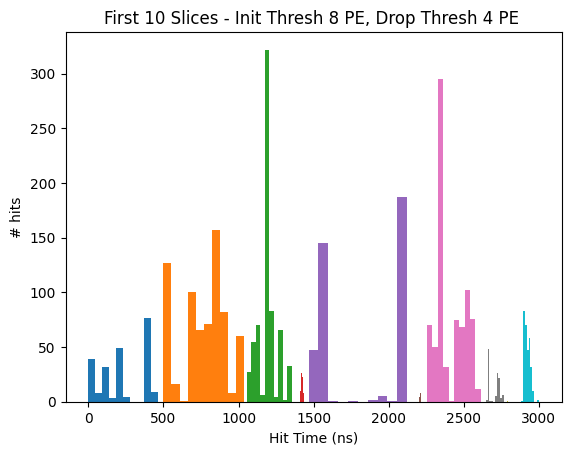

In [26]:
#Generate a timeplot, this can take an arbitrarily high number of slices, but going much above ~15 starts to repeat colors and get squished. 
TimePlot(slice_list, 10, 8, 4)

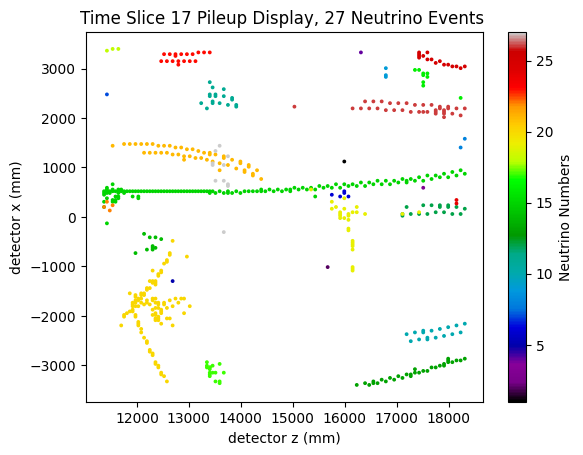

In [27]:
#Generate an event display for a selected time slice
selected_slice = 17
nns = slice_list[selected_slice][:,0]
hit_ns = slice_list[selected_slice][:,1]
hit_xs = slice_list[selected_slice][:,2]
hit_zs = slice_list[selected_slice][:,4]
hit_ts = slice_list[selected_slice][:,5]
hit_PEs = slice_list[selected_slice][:,6]
pileup = len(np.unique(nns))
unique_vals, inverse = np.unique(nns, return_inverse=True)

# Map to 1-based index
mapped = inverse + 1
hit_nns_mapped = mapped

plt.scatter(hit_zs, hit_xs, c = hit_nns_mapped, s = 3, cmap = 'nipy_spectral')
plt.colorbar(label='Neutrino Numbers')
plt.xlabel("detector z (mm)")
plt.ylabel("detector x (mm)")
plt.title(f"Time Slice {selected_slice} Pileup Display, {pileup} Neutrino Events ")
plt.show()

Outputting comparison plots


array([[ 2.10700000e+03,  1.00000000e+01, -7.66651355e+02, ...,
         3.73880047e+00,  1.00000000e+00, -1.00000000e+00],
       [ 2.11500000e+03,  1.37000000e+02, -1.76938219e+03, ...,
         3.08434753e+00,  1.00000000e+00, -1.00000000e+00],
       [ 2.10300000e+03,  1.00000000e+01,  2.54755427e+03, ...,
         8.81687121e+00,  0.00000000e+00, -1.00000000e+00],
       ...,
       [ 2.14200000e+03,  6.40000000e+01,  2.29995406e+03, ...,
         7.78722516e+00,  0.00000000e+00,  6.00000000e+00],
       [ 2.10700000e+03,  0.00000000e+00, -8.37394271e+02, ...,
         3.57240603e+00,  0.00000000e+00, -1.00000000e+00],
       [ 2.14200000e+03,  1.70000000e+01,  1.61556635e+03, ...,
         3.12157262e+00,  0.00000000e+00,  6.00000000e+00]])

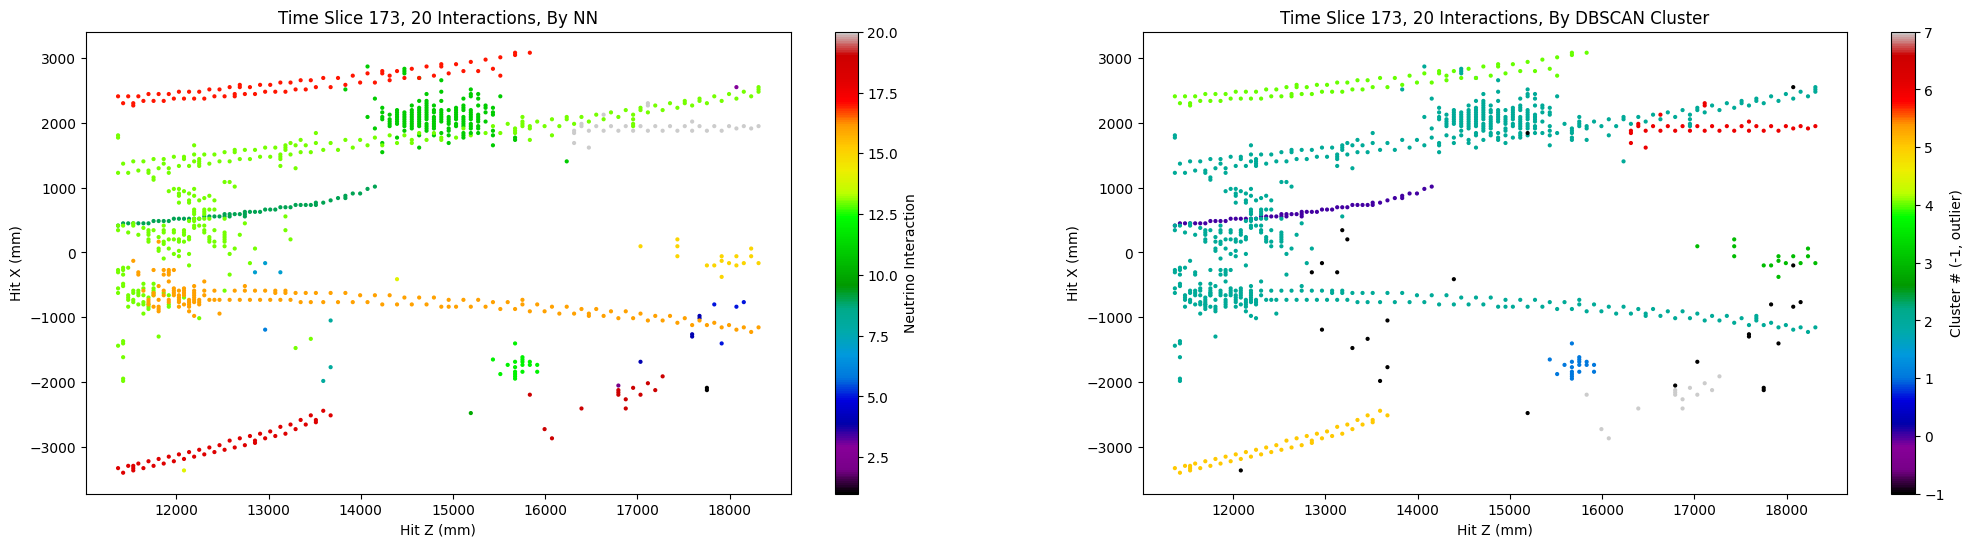

In [60]:
#Clustering! A single example
MakeClustersDBSCAN(slice_list, selected_slice = 173, MinCluster = 6, Epsilon = 0.1, plot = True)

In [54]:
#Example basically only for the purpose of a nice plot:
#Find the most populated slice:
occupancy = []
for i, time_slice in enumerate(slice_list):
    nns = time_slice[:,0]
    uniques = len(np.unique(nns))
    occupancy.append((np.array((i, uniques))))
occupancy_array = np.vstack(occupancy)
ascending_array = occupancy_array[np.argsort(occupancy_array[:,1])]
descending_array = ascending_array[::-1]
for i in range(50):
    print(descending_array[i])



[443  37]
[491  37]
[175  37]
[425  36]
[458  36]
[448  33]
[49 33]
[163  30]
[360  29]
[262  28]
[347  27]
[343  27]
[259  27]
[17 27]
[412  26]
[24 25]
[159  24]
[164  24]
[429  24]
[82 23]
[124  23]
[172  22]
[499  22]
[389  21]
[230  21]
[451  21]
[20 20]
[22 20]
[128  20]
[19 20]
[166  20]
[102  20]
[173  20]
[476  20]
[390  20]
[84 19]
[335  19]
[312  19]
[87 19]
[341  19]
[77 19]
[212  19]
[90 19]
[483  19]
[12 19]
[51 18]
[485  18]
[417  18]
[ 1 18]
[99 17]


In [76]:
#Doing clustering is quite fast which is nice!
slice_list_clustered = FullFileCluster(slice_list_ = slice_list, MinCluster_ = 6, Epsilon_ = 0.1)
#Now run an evaluation on the cluster
neutrino_truth_array = ReturnNeutrinoInfoArray(SortByTime(merged_hits_array), n_neutrino_events) #create a truth array
unmasked_cluster_eval, masked_cluster_eval, cluster_occupancy = ClusterEvaluate(slice_list_clustered, neutrino_truth_array, n_neutrino_events)

Had to use non-normalized clustering for slice 33
Had to use non-normalized clustering for slice 35
Had to use non-normalized clustering for slice 36
Had to use non-normalized clustering for slice 72
Had to use non-normalized clustering for slice 107
Had to use non-normalized clustering for slice 127
Had to use non-normalized clustering for slice 137
Had to use non-normalized clustering for slice 146
Had to use non-normalized clustering for slice 148
Had to use non-normalized clustering for slice 152
Had to use non-normalized clustering for slice 281
Had to use non-normalized clustering for slice 374
Had to use non-normalized clustering for slice 392
Had to use non-normalized clustering for slice 398
Had to use non-normalized clustering for slice 433
Had to use non-normalized clustering for slice 506
Had to use non-normalized clustering for slice 507
Had to use non-normalized clustering for slice 509
Had to use non-normalized clustering for slice 511


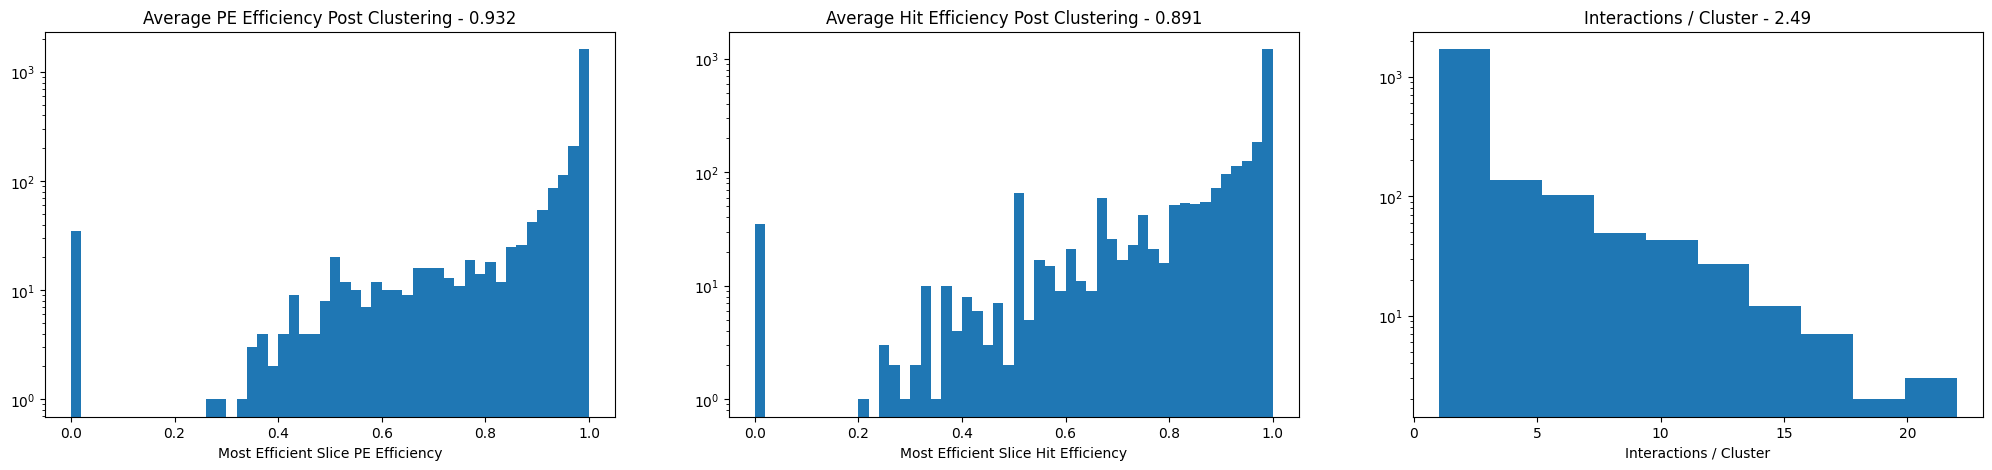

In [81]:
#|nn | hit containment | PE containment | best hit containment slice | best hit containment cluster | best PE containment slice | best PE containment cluster |

fig, axes = plt.subplots(1, 3, figsize=(25, 5)) 

# Plot 1: PE Efficiency Post Clustering
mean_PE_eff = np.mean(masked_cluster_eval[:,2])
axes[0].hist(masked_cluster_eval[:,2], bins=50)
axes[0].set_title(f"Average PE Efficiency Post Clustering - {mean_PE_eff:.3f}")
axes[0].set_xlabel("Most Efficient Slice PE Efficiency")
axes[0].set_yscale('log')

# Plot 2: Hit Efficiency Post Clustering 
mean_hit_eff =np.mean(masked_cluster_eval[:,1])
axes[1].hist(masked_cluster_eval[:,1], bins=50)
axes[1].set_title(f"Average Hit Efficiency Post Clustering - {mean_hit_eff:.3f}")
axes[1].set_xlabel("Most Efficient Slice Hit Efficiency")
axes[1].set_yscale('log')

# Plot 3: Cluster occupancy (interactions / cluster)
avg_cluster_purity = np.mean(cluster_occupancy)
axes[2].hist(cluster_occupancy)
axes[2].set_title(f"Interactions / Cluster - {avg_cluster_purity:.2f}")
axes[2].set_xlabel("Interactions / Cluster")
axes[2].set_yscale('log')

In [15]:
#Print basic metrics for this slice (since single file there is no need to recalculate)
for key in basic_metrics.keys():
    print(f"{key} - {basic_metrics[key].array()[0]}")

init_thresh - 8.0
drop_thresh - 4.0
avg_pe_eff - 0.9511164318596215
avg_hit_eff - 0.9266012055460127
events_per_slice - 8.19140625
missing_hits - 413.0
n_slices - 512.0
file number - 2500


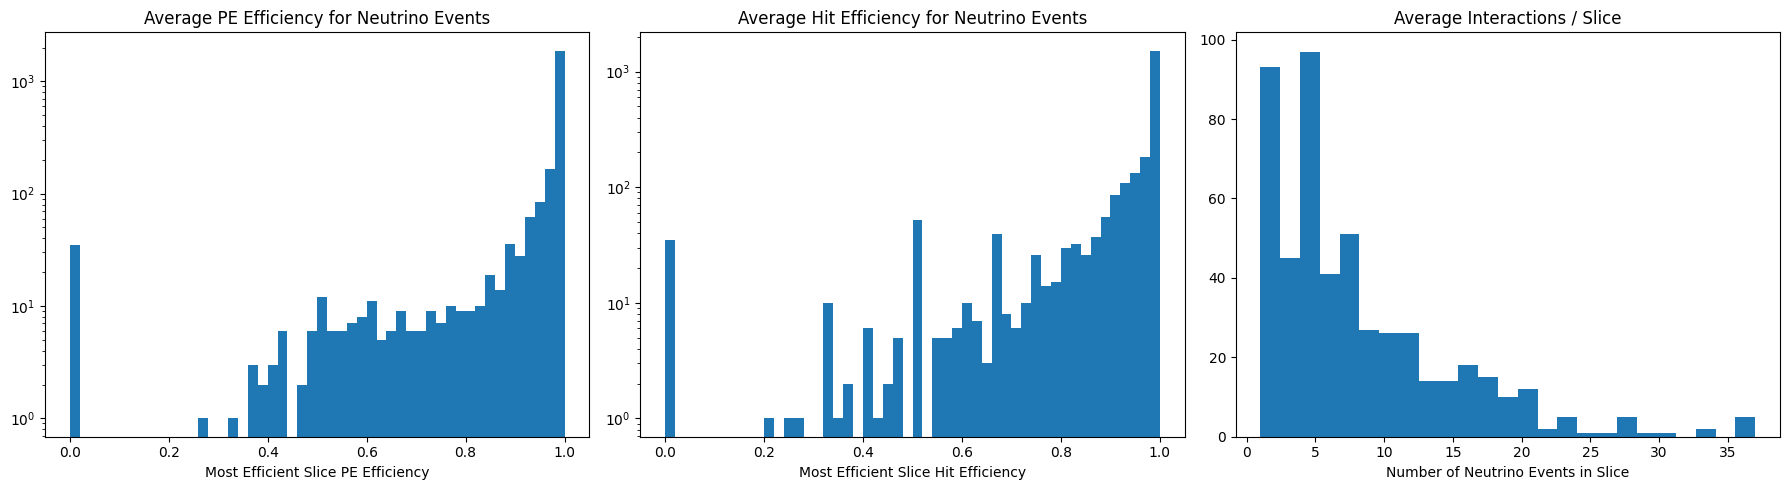

In [16]:
#Now let's generate some histograms based on an actual run of the evaluator
neutrino_PE_array_merged = ReturnNeutrinoInfoArray(SortByTime(merged_hits_array), n_neutrino_events)
containment_array, masked_containment_array, purity_array = SliceEvaluate(slice_list, n_neutrino_events, neutrino_PE_array_merged) #Evaluate the slices.

fig, axes = plt.subplots(1, 3, figsize=(18, 5)) 

# Plot 1: PE Efficiency
axes[0].hist(masked_containment_array[:,2], bins=50)
axes[0].set_title("Average PE Efficiency for Neutrino Events")
axes[0].set_xlabel("Most Efficient Slice PE Efficiency")
axes[0].set_yscale('log')

# Plot 2: Hit Efficiency
axes[1].hist(masked_containment_array[:,1], bins=50)
axes[1].set_title("Average Hit Efficiency for Neutrino Events")
axes[1].set_xlabel("Most Efficient Slice Hit Efficiency")
axes[1].set_yscale('log')

# Plot 3: Slice Purity
axes[2].hist(purity_array[:,1], bins=25)
axes[2].set_title("Average Interactions / Slice")
axes[2].set_xlabel("Number of Neutrino Events in Slice")

plt.tight_layout()
plt.show()

In [17]:
#Lets compare the pre and post clustering containment array
hit_eff_differences = []
PE_eff_differences = []
for i in range(np.shape(masked_containment_array)[0]):
    PE_diff = (masked_containment_array[i][2] - masked_cluster_eval[i][2])
    hit_diff = (masked_containment_array[i][1] - masked_cluster_eval[i][1])
    hit_eff_differences.append(hit_diff)
    PE_eff_differences.append(PE_diff)

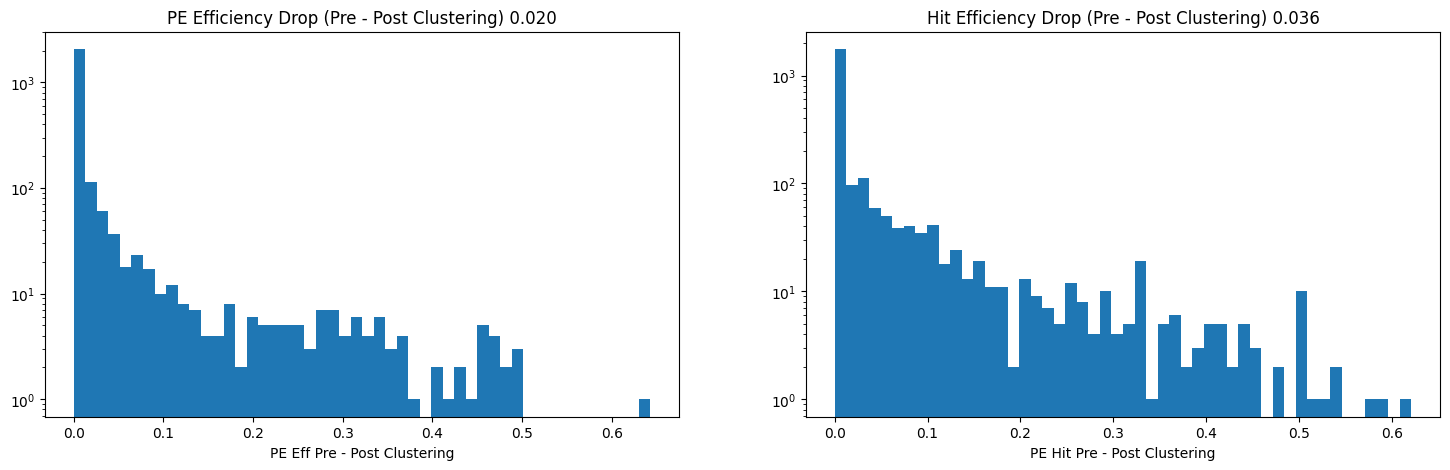

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5)) 

# Plot 1: PE Efficiency
PE_eff_drop_mean = np.mean(PE_eff_differences)
axes[0].hist(PE_eff_differences, bins=50)
axes[0].set_title(f"PE Efficiency Drop (Pre - Post Clustering) {PE_eff_drop_mean:.3f}")
axes[0].set_xlabel("PE Eff Pre - Post Clustering")
axes[0].set_yscale('log')

# Plot 2: Hit Efficiency
hit_eff_drop_mean = np.mean(hit_eff_differences)
axes[1].hist(hit_eff_differences, bins=50)
axes[1].set_title(f"Hit Efficiency Drop (Pre - Post Clustering) {hit_eff_drop_mean:.3f}")
axes[1].set_xlabel("PE Hit Pre - Post Clustering")
axes[1].set_yscale('log')

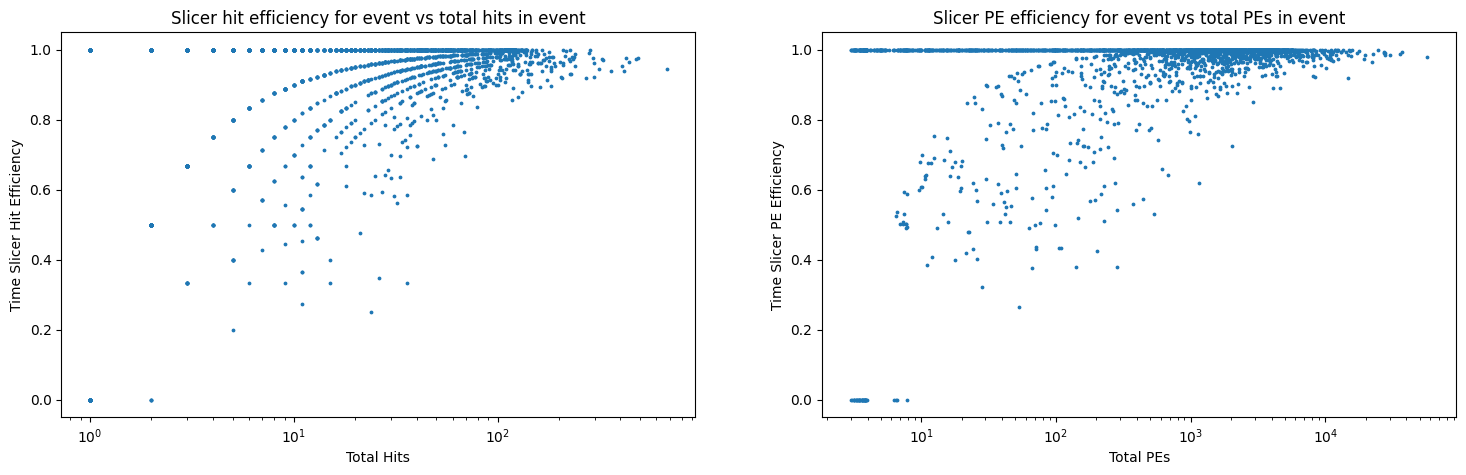

In [82]:
#Hit and PE efficiency vs total hit and PE
event_hits = []
event_PEs = []
event_hit_eff = []
event_PE_eff = []
for row in masked_containment_array:
    nn = row[0]
    hits = (neutrino_PE_array_merged[neutrino_PE_array_merged[:,0] == nn])[0][2]
    PEs = (neutrino_PE_array_merged[neutrino_PE_array_merged[:,0] == nn])[0][1]
    hit_eff = row[1]
    PE_eff = row[2]
    event_hits.append(hits)
    event_PEs.append(PEs)
    event_hit_eff.append(hit_eff)
    event_PE_eff.append(PE_eff)

fig, axes = plt.subplots(1, 2, figsize=(18, 5)) 

axes[0].scatter(event_hits, event_hit_eff, s=3)
axes[0].set_title("Slicer hit efficiency for event vs total hits in event")
axes[0].set_xlabel("Total Hits")
axes[0].set_ylabel("Time Slicer Hit Efficiency")
axes[0].set_xscale('log')


axes[1].scatter(event_PEs, event_PE_eff, s=3)
axes[1].set_title("Slicer PE efficiency for event vs total PEs in event")
axes[1].set_xlabel("Total PEs")
axes[1].set_ylabel("Time Slicer PE Efficiency")
axes[1].set_xscale('log')

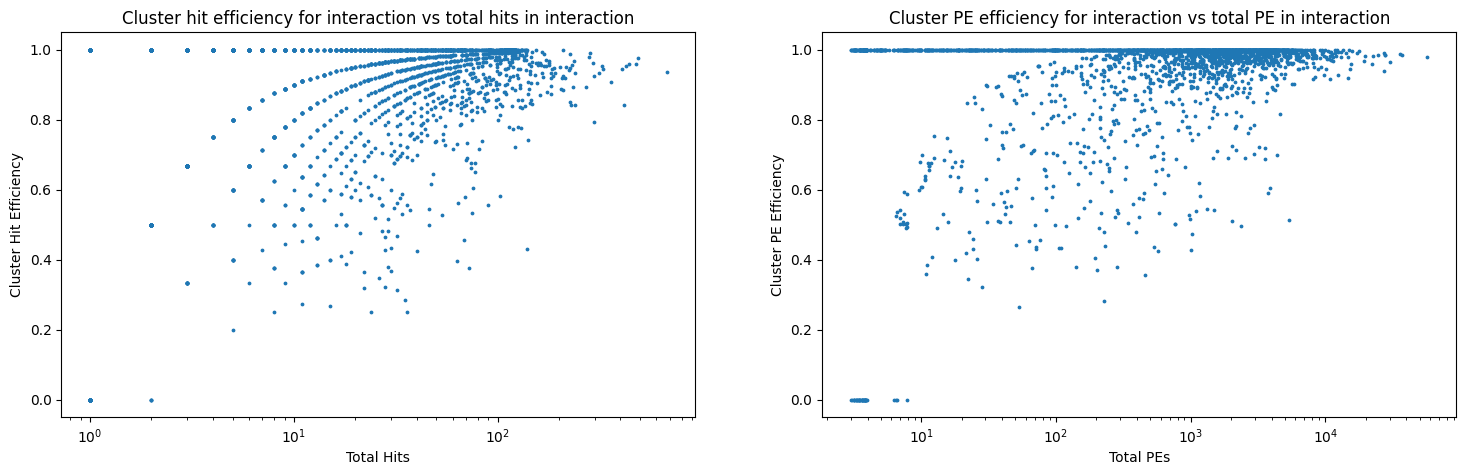

In [84]:
#Hit and PE efficiency vs total hit and PE - for clustering 
cluster_event_hits = []
cluster_event_PEs = []
cluster_event_hit_eff = []
cluster_event_PE_eff = []
for row in masked_cluster_eval:
    nn = row[0]
    hits = (neutrino_PE_array_merged[neutrino_PE_array_merged[:,0] == nn])[0][2]
    PEs = (neutrino_PE_array_merged[neutrino_PE_array_merged[:,0] == nn])[0][1]
    hit_eff = row[1]
    PE_eff = row[2]
    cluster_event_hits.append(hits)
    cluster_event_PEs.append(PEs)
    cluster_event_hit_eff.append(hit_eff)
    cluster_event_PE_eff.append(PE_eff)

fig, axes = plt.subplots(1, 2, figsize=(18, 5)) 

axes[0].scatter(cluster_event_hits, cluster_event_hit_eff, s=3)
axes[0].set_title("Cluster hit efficiency for interaction vs total hits in interaction")
axes[0].set_xlabel("Total Hits")
axes[0].set_ylabel("Cluster Hit Efficiency")
axes[0].set_xscale('log')


axes[1].scatter(cluster_event_PEs, cluster_event_PE_eff, s=3)
axes[1].set_title("Cluster PE efficiency for interaction vs total PE in interaction")
axes[1].set_xlabel("Total PEs")
axes[1].set_ylabel("Cluster PE Efficiency")
axes[1].set_xscale('log')

This next portion of the script can handle an entire directory of time sliced files at once! Also needs a merged hits file ofc...

In [67]:
%%time
#Let's pull the global statistics first (so hit eff, PE eff, purity, etc across many files)
#This cell can take a while to run.
time_sliced_directory = '/sdf/data/neutrino/summer25/ktwall/tms_timing/time_sliced/' #put your time sliced directory here
multi_merged_directory = '/sdf/data/neutrino/summer25/ktwall/tms_timing/multihit/' #put your 
time_file_paths = glob.glob(os.path.join(time_sliced_directory, "*.root")) #glob can grab all files that fit the *.root condition, forms list of them!
multi_file_paths = glob.glob(os.path.join(multi_merged_directory, "*.npz")) 

PE_effs = []
hit_effs = []
purities = []

#This generates a neutrino truth dictionary, will be keyed in next cell
neutrino_truth_dict = {}
for multi_file_path in multi_file_paths:
    with np.load(multi_file_path) as multi_file:
        merged_hit_array = multi_file['first']
        n_neutrino_events = multi_file['second']
        file_number = merged_hit_array[0][-1]
        neutrino_PE_array_merged = ReturnNeutrinoInfoArray(SortByTime(merged_hit_array), n_neutrino_events)
        #print(neutrino_PE_array_merged)
        neutrino_truth_dict[file_number] = neutrino_PE_array_merged
        print(file_number)
        #print(neutrino_truth_dict[file_number])
        #print(file_number)

2555.0
[[0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [1.00000000e+00 4.25043463e+01 9.00000000e+00]
 [2.00000000e+00 0.00000000e+00 0.00000000e+00]
 ...
 [5.98700000e+03 1.95305836e+03 5.00000000e+01]
 [5.98800000e+03 1.52266479e+02 1.00000000e+00]
 [5.98900000e+03 0.00000000e+00 0.00000000e+00]]
2553.0
[[0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [1.00000000e+00 0.00000000e+00 0.00000000e+00]
 [2.00000000e+00 1.05716570e+03 1.60000000e+01]
 ...
 [5.87400000e+03 0.00000000e+00 0.00000000e+00]
 [5.87500000e+03 1.07636180e+03 2.40000000e+01]
 [5.87600000e+03 2.43980052e+03 9.00000000e+01]]
2515.0
[[0.00000000e+00 3.44838088e+03 1.16000000e+02]
 [1.00000000e+00 0.00000000e+00 0.00000000e+00]
 [2.00000000e+00 0.00000000e+00 0.00000000e+00]
 ...
 [5.36500000e+03 0.00000000e+00 0.00000000e+00]
 [5.36600000e+03 0.00000000e+00 0.00000000e+00]
 [5.36700000e+03 0.00000000e+00 0.00000000e+00]]
2536.0
[[0.00000000e+00 3.69104675e+00 1.00000000e+00]
 [1.00000000e+00 3.66086221e+00 1.00000000

In [83]:
%%time
#This does some processing to pull groups statistics on a set of files. 

PE_effs = []
hit_effs = []
purities = []
soft_cap = 60 #will artificially limit number of files processed for testing
for i, time_file_path in enumerate(time_file_paths):
    if i < soft_cap:
        #careful to reset variables lol, could be memory leaks
        time_slices = 0
        file_number = 0
        relevant_truth_array = 0
        n_neutrino_events = 0
        slice_list = 0
        with uproot.open(time_file_path) as time_file:
            time_slices = time_file['Time Slices'] #first grab the time slices from the file
            file_number = time_file['Metrics']['file number'].array()[0]
            print(f"starting file {time_file_path}")
            #print(file_number)
            relevant_truth_array = np.copy(neutrino_truth_dict[file_number])
            n_neutrino_events = np.shape(relevant_truth_array)[0] 
            #print(n_neutrino_events)
            slice_list = UnpackRoot(time_slices)
            #print(relevant_truth_array)
            containment_array, masked_containment_array, purity_array = SliceEvaluate(slice_list, n_neutrino_events, relevant_truth_array)
            #now convert to the format we need. This step is slow!!
            hit_effs.append(masked_containment_array[:,1])
            PE_effs.append(masked_containment_array[:,2])
            purities.append(purity_array[:,1])
            print(f"processed file {file_number}")
    else:
        break

starting file /sdf/data/neutrino/summer25/ktwall/tms_timing/time_sliced/file_2548_sliced_init-8.0_drop-4.0.root
processed file 2548
starting file /sdf/data/neutrino/summer25/ktwall/tms_timing/time_sliced/file_2519_sliced_init-8.0_drop-4.0.root
processed file 2519
starting file /sdf/data/neutrino/summer25/ktwall/tms_timing/time_sliced/file_2520_sliced_init-8.0_drop-4.0.root
processed file 2520
starting file /sdf/data/neutrino/summer25/ktwall/tms_timing/time_sliced/file_2551_sliced_init-8.0_drop-4.0.root
processed file 2551
starting file /sdf/data/neutrino/summer25/ktwall/tms_timing/time_sliced/file_2524_sliced_init-8.0_drop-4.0.root
processed file 2524
starting file /sdf/data/neutrino/summer25/ktwall/tms_timing/time_sliced/file_2535_sliced_init-8.0_drop-4.0.root
processed file 2535
starting file /sdf/data/neutrino/summer25/ktwall/tms_timing/time_sliced/file_2502_sliced_init-8.0_drop-4.0.root
processed file 2502
starting file /sdf/data/neutrino/summer25/ktwall/tms_timing/time_sliced/file

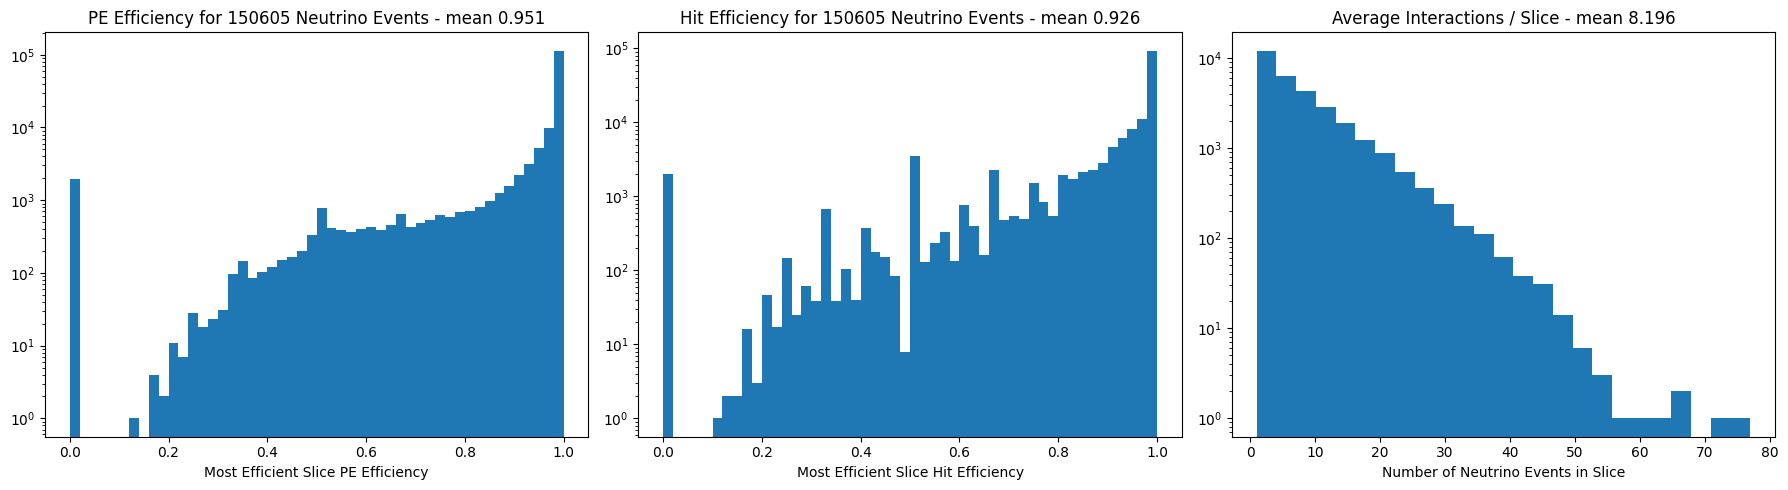

In [94]:
big_PE_effs = np.concatenate(PE_effs)
big_hit_effs = np.concatenate(hit_effs)
big_purities = np.concatenate(purities)

PE_eff_avg = np.mean(big_PE_effs)
hit_eff_avg = np.mean(big_hit_effs)
purities_avg = np.mean(big_purities)

n_events = len(big_hit_effs)

fig, axes = plt.subplots(1, 3, figsize=(18, 5)) 

# Plot 1: PE Efficiency
axes[0].hist(big_PE_effs, bins=50)
axes[0].set_title(f"PE Efficiency for {n_events} Neutrino Events - mean {PE_eff_avg:.3f}")
axes[0].set_xlabel("Most Efficient Slice PE Efficiency")
axes[0].set_yscale('log')

# Plot 2: Hit Efficiency
axes[1].hist(big_hit_effs, bins=50)
axes[1].set_title(f"Hit Efficiency for {n_events} Neutrino Events - mean {hit_eff_avg:.3f}")
axes[1].set_xlabel("Most Efficient Slice Hit Efficiency")
axes[1].set_yscale('log')

# Plot 3: Slice Purity
axes[2].hist(big_purities, bins=25)
axes[2].set_title(f"Average Interactions / Slice - mean {purities_avg:.3f}")
axes[2].set_xlabel("Number of Neutrino Events in Slice")
axes[2].set_yscale('log')

plt.tight_layout()
plt.show()